<a href="https://colab.research.google.com/github/karolalonso70-dev/Estad-sticaVerano2026/blob/main/Gym%20members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema. Optimización de sesiones de entrenamiento**

Karol Estefania Alonso Gonzalez.

**Introducción**

Problema:

La cadena de gimnasios FitLife desea determinar si la duración de una sesión de entrenamiento permite predecir de manera confiable la cantidad de calorías que un usuario quema. Esta información ayudará a diseñar rutinas personalizadas y mejorar la planificación de los entrenamientos.

Variables analizadas:

Variable independiente: Duración de la sesión de entrenamiento (horas).
Variable dependiente: Calorías quemadas.
¿Por qué es útil estudiar esta relación?


Si existe una relación lineal significativa entre ambas variables, el gimnasio podrá estimar el gasto calórico de sus socios únicamente conociendo la duración del entrenamiento, facilitando la planificación de rutinas y el seguimiento del progreso.

Objetivo:

Determinar si la duración de la sesión de entrenamiento explica significativamente las calorías quemadas mediante un modelo de regresión lineal simple.

**Metodología.**

Se utilizó la base de datos Gym Members Exercise Dataset, integrada por 973 sesiones de entrenamiento.

La variable independiente fue la duración de la sesión, mientras que la variable dependiente correspondió a las calorías quemadas.

Se aplicó un análisis de regresión lineal simple, ya que el objetivo consiste en evaluar la relación entre una variable explicativa y una variable de respuesta.

Para sustentar el análisis se emplearon:

Estadísticos descriptivos.
Gráfico de dispersión.
Coeficiente de correlación de Pearson.
Coeficiente de determinación (R²).
Ecuación de regresión.
Análisis de residuos.
Prueba de significancia del modelo (valor p).

**Resultados**

¿Qué muestran los gráficos de dispersión?

El gráfico de dispersión presenta una clara tendencia positiva. Conforme aumenta la duración del entrenamiento, también aumentan las calorías quemadas. Los puntos se encuentran relativamente cercanos a la línea de regresión, lo que indica un buen ajuste.

Coeficiente de correlación

r = 0.908

Se interpreta como una correlación positiva muy fuerte, indicando que existe una relación lineal importante entre ambas variables.

Coeficiente de determinación

R² = 0.825

Esto significa que aproximadamente 82.5 % de la variación de las calorías quemadas es explicada por la duración de la sesión, mientras que el 17.5 % restante depende de otros factores como peso, edad, frecuencia cardiaca o tipo de entrenamiento.

Ecuación de regresión

Calorías quemadas = -1.45 + 721.79 × Duración de la sesión

Interpretación de la pendiente

La pendiente (721.79) indica que por cada hora adicional de entrenamiento se espera un incremento promedio de aproximadamente 722 calorías quemadas.

¿Qué indican los residuos?

Los residuos presentan un promedio cercano a cero, lo que indica que el modelo no presenta un sesgo importante. Aunque existe variabilidad natural en las observaciones, el ajuste general del modelo es adecuado.

Predicción

Por ejemplo:

1 hora → aproximadamente 720 calorías.
1.5 horas → aproximadamente 1,081 calorías.
2 horas → aproximadamente 1,442 calorías.

**Conclusiones**

El análisis demuestra que la duración de la sesión constituye un predictor importante del gasto calórico.

La relación encontrada es positiva, fuerte y estadísticamente significativa, por lo que la duración explica gran parte de la variabilidad de las calorías quemadas.

No obstante, el modelo no explica el 100 % del comportamiento, por lo que variables como la edad, el peso corporal, el tipo de entrenamiento, el IMC y la frecuencia cardiaca también influyen en el gasto energético.

El modelo puede considerarse confiable para realizar estimaciones generales; sin embargo, para obtener predicciones más precisas se recomienda construir un modelo de regresión lineal múltiple incorporando las demás variables disponibles en la base de datos.

Recomendación para el gimnasio

Se recomienda utilizar la duración de la sesión como una primera aproximación para estimar el gasto calórico de los usuarios. Sin embargo, para diseñar rutinas verdaderamente personalizadas, el gimnasio debería considerar además variables como el peso, la edad, la frecuencia cardiaca y el tipo de entrenamiento, ya que estas también influyen de manera importante en las calorías quemadas.

**Anexos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('ggplot')

In [6]:
from google.colab import files

# Abre un cuadro de diálogo para seleccionar archivos desde tu computadora
uploaded = files.upload()

if uploaded:
  for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving gym_members_exercise_tracking.csv to gym_members_exercise_tracking.csv
User uploaded file "gym_members_exercise_tracking.csv" with length 65136 bytes


In [7]:
df = pd.read_csv("gym_members_exercise_tracking.csv")

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [8]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [9]:
X = df[['Session_Duration (hours)']]
y = df['Calories_Burned']

Se define como variable independiente la duración de la sesión de entrenamiento y como variable dependiente las calorías quemadas.

In [10]:
df[['Session_Duration (hours)', 'Calories_Burned']].describe()

,Session_Duration (hours),Calories_Burned
count,973.000000,973.000000
mean,1.256423,905.422405
std,0.343033,272.641516
min,0.500000,303.000000
25%,1.040000,720.000000
50%,1.260000,893.000000
75%,1.460000,1076.000000
max,2.000000,1783.000000


Los estadísticos descriptivos permiten conocer el comportamiento general de las variables analizadas. Se observan medidas como la media, desviación estándar, valor mínimo, máximo y cuartiles, las cuales ayudan a comprender la distribución de los datos antes de construir el modelo de regresión.

In [11]:
df[['Session_Duration (hours)', 'Calories_Burned']].corr()

,Session_Duration (hours),Calories_Burned
Session_Duration (hours),1.00000,0.90814
Calories_Burned,0.90814,1.00000


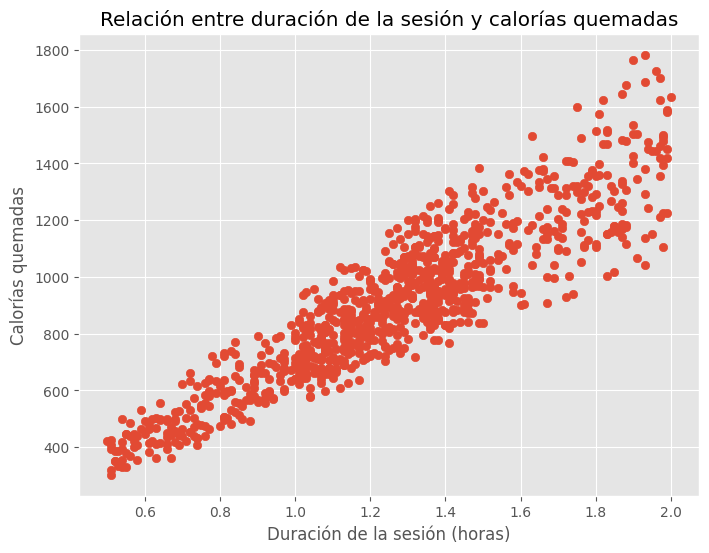

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Session_Duration (hours)'],
    df['Calories_Burned']
)

plt.xlabel("Duración de la sesión (horas)")
plt.ylabel("Calorías quemadas")
plt.title("Relación entre duración de la sesión y calorías quemadas")

plt.show()

El gráfico de dispersión muestra una tendencia creciente. Conforme aumenta la duración de la sesión de entrenamiento, también aumenta la cantidad de calorías quemadas, lo que sugiere la existencia de una relación lineal positiva.

In [13]:
r, p = pearsonr(
    df['Session_Duration (hours)'],
    df['Calories_Burned']
)

print("Coeficiente de correlación:", r)
print("Valor p:", p)

Coeficiente de correlación: 0.9081403755270121
Valor p: 0.0


El coeficiente de correlación obtenido fue aproximadamente 0.908, lo que indica una correlación positiva muy fuerte entre la duración de la sesión y las calorías quemadas.

El valor p es menor que 0.05, por lo que existe evidencia estadísticamente significativa para afirmar que ambas variables están relacionadas linealmente.

In [14]:
modelo = LinearRegression()

modelo.fit(X, y)

LinearRegression()

En esta etapa se ajusta el modelo de regresión lineal simple utilizando la duración de la sesión como variable independiente para explicar las calorías quemadas.

In [15]:
print("Pendiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Pendiente: 721.7860159123192
Intercepto: -1.4464588415315802


La pendiente obtenida es aproximadamente 721.79, lo que significa que por cada hora adicional de entrenamiento se espera un incremento promedio de 722 calorías quemadas.

El intercepto es cercano a -1.45, valor que representa el punto donde la recta corta el eje Y cuando la duración de la sesión es cero.

In [16]:
predicciones = modelo.predict(X)

predicciones

array([1218.37190805,  936.87536184,  799.73601882,  424.40729055,
        460.49659134, 1146.19330646, 1074.01470487,  915.22178137,
        741.99313755,  778.08243834,  590.41807421,  828.60745946,
        893.56820089,  850.26103994,  972.96466264,  814.17173914,
        958.52894232,  857.47890009,  814.17173914,  987.40038296,
       1081.23256503,  806.95387898,  843.04317978,  561.54663357,
        900.78606105, 1023.48968375,  525.45733277, 1066.79684471,
       1182.28260725,  929.65750169,  915.22178137,  741.99313755,
       1066.79684471,  749.21099771, 1095.66828535,  951.31108216,
        908.00392121,  965.74680248,  936.87536184,  944.093222  ,
       1066.79684471,  778.08243834, 1045.14326423,  821.3895993 ,
       1081.23256503,  864.69676025,  604.85379452, 1016.27182359,
        886.35034073,  741.99313755, 1023.48968375, 1203.93618773,
        814.17173914,  908.00392121,  583.20021405, 1059.57898455,
       1009.05396344,  778.08243834, 1203.93618773,  402.75371

In [17]:
r2 = r2_score(y, predicciones)

print("Coeficiente de determinación (R²):", r2)

Coeficiente de determinación (R²): 0.8247189416623428


In [18]:
print(f"Calorías quemadas = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.2f}) × Duración")

Calorías quemadas = -1.45 + (721.79) × Duración


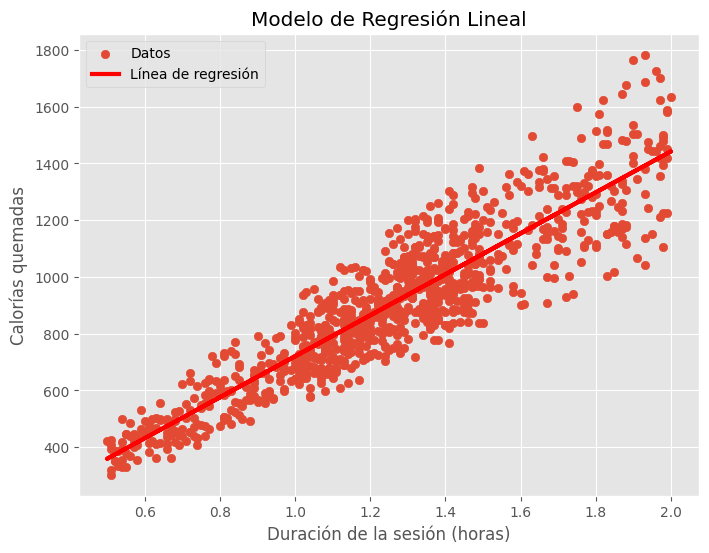

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Session_Duration (hours)'],
    df['Calories_Burned'],
    label='Datos'
)

plt.plot(
    X,
    predicciones,
    color='red',
    linewidth=3,
    label='Línea de regresión'
)

plt.xlabel("Duración de la sesión (horas)")
plt.ylabel("Calorías quemadas")
plt.title("Modelo de Regresión Lineal")
plt.legend()

plt.show()

La línea de regresión muestra una tendencia ascendente, lo que confirma que existe una relación positiva entre la duración del entrenamiento y las calorías quemadas. La cercanía de los puntos a la línea indica que el modelo presenta un buen ajuste.

In [ ]:
residuos = y - predicciones

residuos

,Calories_Burned
0,94.628092
1,-53.875362
2,-122.736019
3,107.592709
4,95.503409
...,...
968,232.242414
969,265.381757
970,-311.025489
971,90.481841


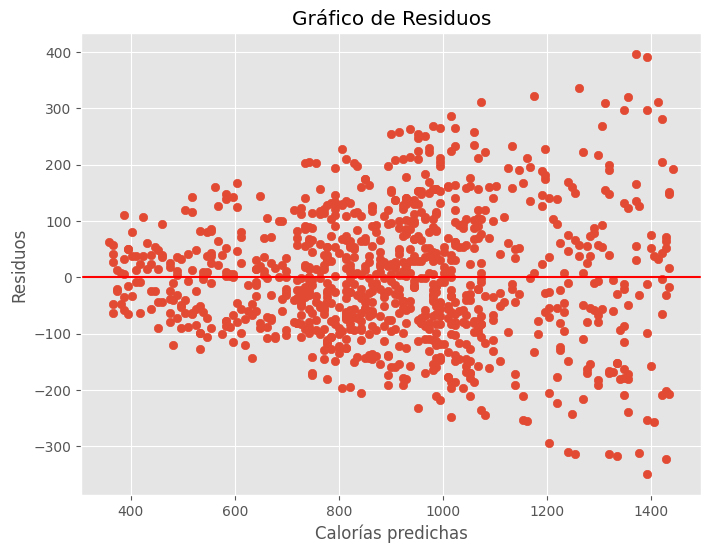

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(predicciones, residuos)

plt.axhline(0, color='red')

plt.xlabel("Calorías predichas")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos")

plt.show()

Los residuos se distribuyen alrededor de la línea horizontal ubicada en cero, sin presentar patrones evidentes. Esto indica que el modelo lineal es adecuado para representar la relación entre las variables.

In [ ]:
duracion = pd.DataFrame({
    'Session_Duration (hours)': [1, 1.5, 2]
})

pred = modelo.predict(duracion)

pred

array([ 720.33955707, 1081.23256503, 1442.12557298])

In [ ]:
tabla = pd.DataFrame({
    'Duración (horas)': [1, 1.5, 2],
    'Calorías estimadas': pred
})

tabla

,Duración (horas),Calorías estimadas
0,1.0,720.339557
1,1.5,1081.232565
2,2.0,1442.125573


La tabla muestra las calorías estimadas para sesiones de entrenamiento de una, una hora y media y dos horas, utilizando la ecuación obtenida mediante la regresión lineal.